In [82]:
# pyright: reportUnusedExpression=false
from pathlib import Path
import os

def find_repo_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'pyproject.toml').exists():
            return parent
    return start

REPO_ROOT = find_repo_root(Path.cwd())

if 'NEPTUNE_API_TOKEN' not in os.environ:
    os.environ.setdefault('NEPTUNE_MODE', 'offline')

os.chdir(REPO_ROOT)


In [83]:
import numpy as np
from joblib import load
from loguru import logger
from torch import Tensor
from transformers import BartForConditionalGeneration, BertForSequenceClassification
import plotly.io as pio
pio.renderers.default = "svg" # uncomment this if want interactive renderer
from carl.environment.sokoban.tokenizer import SokobanTokenizer
from carl.environment.sokoban.env import SokobanEnv

from carl.inference_components.conditional_low_level_policy import (
    ConditionalLowLevelPolicy,
    TransformerConditionalLowLevelPolicy,
)
from carl.inference_components.policy import Policy, TransformerPolicy
from carl.inference_components.subgoal_generator import (
    SubgoalGenerator,
    TransformerSubgoalGenerator,
)
from carl.inference_components.value import TransformerValue, Value

logger.info('testing inference components')

2025-12-28 19:07:23.835 | INFO     | __main__:<module>:22 - testing inference components


# Env and dataset

Loading assets from package: carl.environment.sokoban


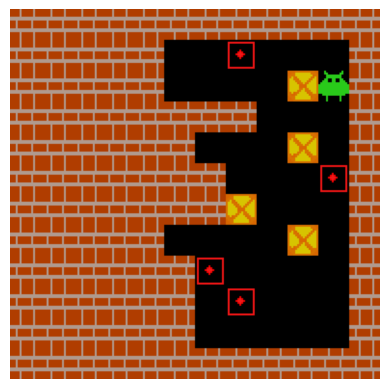

In [84]:
import joblib as jl
datapath = str(REPO_ROOT / "rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35/boards_1000_b4_gs100_c300_p0.35.joblib")
data = jl.load(datapath)

env = SokobanEnv(SokobanTokenizer(None, size_of_board=(12, 12)), num_boxes=4)
env.state_to_repr(data[0])

2025-12-28 19:07:24.061 | INFO     | __main__:<module>:1 - setting up the environment
2025-12-28 19:07:24.075 | INFO     | __main__:<module>:2 - It is important to set the categorical distance to 100, because the model was trained with this value. Also the size of the board should be (12, 12), because the model was trained with this value.


Loading assets from package: carl.environment.sokoban


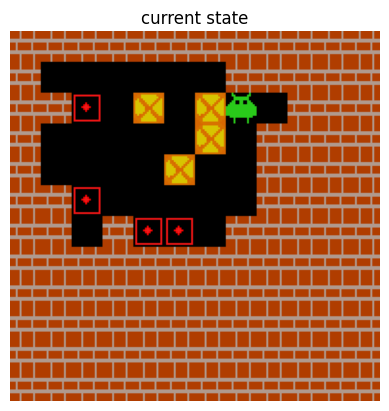

2025-12-28 19:07:24.986 | INFO     | __main__:<module>:14 - state after k is the state after k steps, where k is the number of steps the agent should take. In this case k = 3.


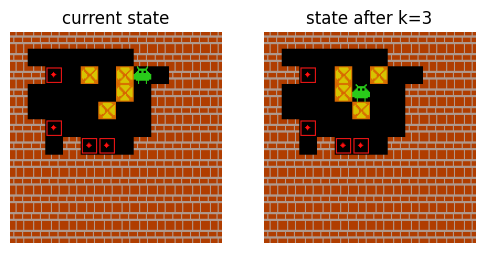

In [85]:
logger.info('setting up the environment')
logger.info(
    'It is important to set the categorical distance to 100, because the model was trained with this value. Also the '
    'size of the board should be (12, 12), because the model was trained with this value.'
)
env = SokobanEnv(SokobanTokenizer(cut_distance=None, size_of_board=(12, 12)), num_boxes=4)

# logger.info('setting up the dataset')
path_to_dataset: str = str(REPO_ROOT / "rl-data/validation/sokoban/offline/12-12-4/sokoban_12_12_4_trajectories_part_88.pkl")
dataset: dict[int, list[np.ndarray]] = load(path_to_dataset)
keys = list(dataset.keys())
current_state: np.ndarray = dataset[keys[1]][1]
display(env.state_to_repr(current_state, title='current state'))
logger.info(
    'state after k is the state after k steps, where k is the number of steps the agent should take. In this '
    'case k = 3.'
)
state_after_k: np.ndarray = dataset[keys[1]][4]
display(env.many_states_to_repr([current_state, state_after_k], titles=['current state', 'state after k=3']))

In [86]:
from carl.environment.instance_generator import (
    GeneralIterableDataLoader,
    BasicInstanceGenerator,
)

# rl-data/validation/sokoban/offline/12-12-4
path_to_folder_with_data = str(REPO_ROOT / "rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35")   # path to the folder with trajectories
# its a dict mapping id of trajectory to the list of states in this trajectory
env = SokobanEnv(SokobanTokenizer(None, size_of_board=(12, 12)), num_boxes=4)
instance_generator = BasicInstanceGenerator(
    generator=GeneralIterableDataLoader(path_to_folder_with_data), batch_size=32
)


initial_state_loader = iter(instance_generator.reset_dataloader())
initial_state = next(initial_state_loader).cpu().numpy()
initial_state.shape, type(initial_state), initial_state.dtype

2025-12-28 19:07:25.253 | DEBUG    | carl.environment.instance_generator:__init__:35 - path: /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35
2025-12-28 19:07:25.258 | DEBUG    | carl.environment.instance_generator:get_stream:54 - Found 1 files in /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35
2025-12-28 19:07:25.262 | INFO     | carl.environment.instance_generator:process_data:44 - Processing data from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35/boards_1000_b4_gs25_c300_p0.35.joblib


Loading assets from package: carl.environment.sokoban


((32, 12, 12, 7), numpy.ndarray, dtype('uint8'))

(12, 12, 7)


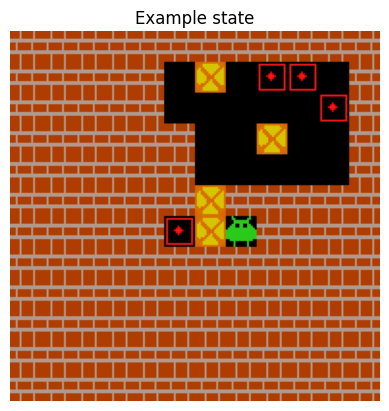

In [87]:
env.set_state(initial_state[0, :])
print(env.get_state().shape)
env.state_to_repr(env.get_state(), 'Example state')

2025-12-28 19:07:25.441 | DEBUG    | carl.environment.instance_generator:get_stream:54 - Found 1 files in /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35
2025-12-28 19:07:25.445 | INFO     | carl.environment.instance_generator:process_data:44 - Processing data from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35/boards_1000_b4_gs25_c300_p0.35.joblib


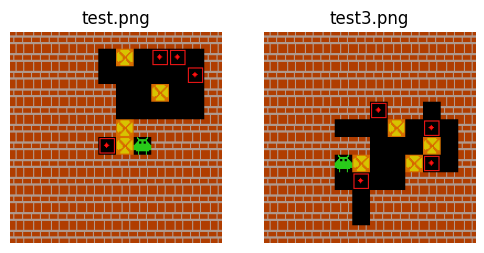

In [88]:
dataloader = iter(instance_generator.reset_dataloader())
state = next(dataloader).cpu().numpy()[0]
state3 = next(dataloader).cpu().numpy()[0]
env.many_states_to_repr([state, state3], ['test.png', 'test3.png'])

In [89]:
components_prefix = str(REPO_ROOT / "rl-data/validation/sokoban/components/full_data") + '/'
from os.path import join

path_to_policy_weights: str = join(components_prefix, 'policy/checkpoint-94820')
path_to_cllp_weights: str = join(components_prefix, 'cllp/8/checkpoint-167585')
path_to_value_function_weights: str = join(components_prefix, 'value/checkpoint-1343100')
path_to_generator_weights: str = join(components_prefix, 'generator/border/8/checkpoint-75856')

# Policy
### CurrentState $\rightarrow$ Action

In [90]:
current_state.shape

(12, 12, 7)

In [91]:
logger.info('setting up the policy')

policy: Policy = TransformerPolicy(
    policy_network_class=BertForSequenceClassification.from_pretrained,
    path_to_policy_weights=path_to_policy_weights,
    env=env,
    n_actions=2,
)
policy.construct_network()
policy_prediction: Tensor = policy.get_actions(current_state)

logger.info(f'policy prediction - distribution over action: {policy_prediction}')
logger.info(f'Proposed {len(policy_prediction)} actions')
logger.info(f'policy prediction - best action ({policy_prediction[0][0]}) with value {policy_prediction[0][1]}')

2025-12-28 19:07:25.655 | INFO     | __main__:<module>:1 - setting up the policy
2025-12-28 19:07:25.667 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/policy/checkpoint-94820
2025-12-28 19:07:25.669 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:07:25.779 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/policy/checkpoint-94820


True
Using device: cpu


2025-12-28 19:07:25.874 | INFO     | __main__:<module>:12 - policy prediction - distribution over action: [GeneratedAction(action=2, generation_metadata={'action_probs': tensor([-3.3795,  3.1019,  4.6949, -3.4125])}), GeneratedAction(action=1, generation_metadata={'action_probs': tensor([-3.3795,  3.1019,  4.6949, -3.4125])})]
2025-12-28 19:07:25.877 | INFO     | __main__:<module>:13 - Proposed 2 actions
2025-12-28 19:07:25.883 | INFO     | __main__:<module>:14 - policy prediction - best action (2) with value {'action_probs': tensor([-3.3795,  3.1019,  4.6949, -3.4125])}


2025-12-28 19:07:25.974 | INFO     | __main__:<module>:12 - Action: 3
2025-12-28 19:07:26.036 | INFO     | __main__:<module>:12 - Action: 1
2025-12-28 19:07:26.083 | INFO     | __main__:<module>:12 - Action: 1
2025-12-28 19:07:26.134 | INFO     | __main__:<module>:12 - Action: 1
2025-12-28 19:07:26.182 | INFO     | __main__:<module>:12 - Action: 2


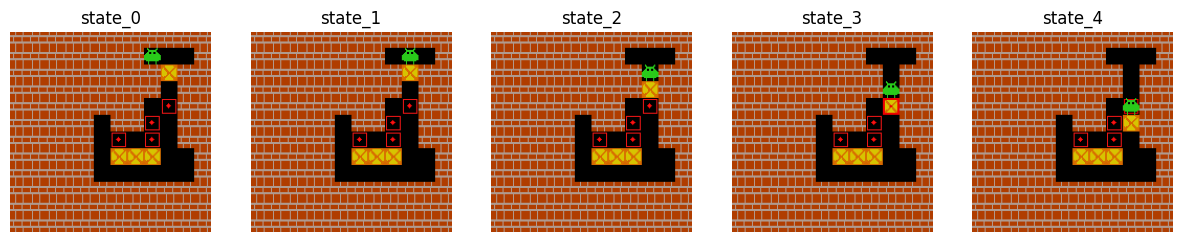

In [92]:
# Lets visualize the policy we have learned

input_state = next(dataloader).cpu().numpy()[0]


visited_states = []
current_state = input_state
for i in range(5):
    visited_states.append(current_state.copy())
    action = policy.get_actions(current_state)
    action = action[0][0]
    logger.info(f'Action: {action}')
    env.set_state(current_state)
    state, _, done, _ = env.step(action)

    current_state = state

    if done:
        break

    if done:
        break

env.many_states_to_repr(
    visited_states, titles=[f'state_{i}' for i in range(len(visited_states) + 1)]
)

# Conditional Low Level Policy
### CurrentState $\times$ SubgoalState $\rightarrow$ Action

In [93]:
cllp: ConditionalLowLevelPolicy = TransformerConditionalLowLevelPolicy(
    BertForSequenceClassification.from_pretrained, path_to_cllp_weights, env
)
cllp.construct_network()

2025-12-28 19:07:26.458 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/cllp/8/checkpoint-167585
2025-12-28 19:07:26.465 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:07:26.567 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/cllp/8/checkpoint-167585


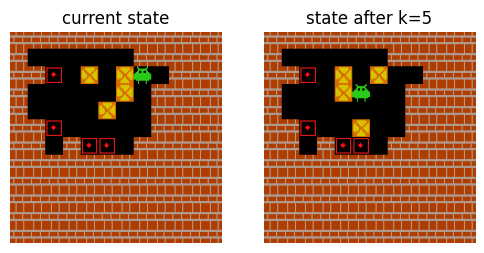

2025-12-28 19:07:26.939 | INFO     | __main__:<module>:15 - Action: 1
2025-12-28 19:07:27.021 | INFO     | __main__:<module>:15 - Action: 2
2025-12-28 19:07:27.103 | INFO     | __main__:<module>:15 - Action: 2
2025-12-28 19:07:27.186 | INFO     | __main__:<module>:15 - Action: 1
2025-12-28 19:07:27.276 | INFO     | __main__:<module>:15 - Action: 0
2025-12-28 19:07:27.280 | SUCCESS  | __main__:<module>:11 - Reached the goal state


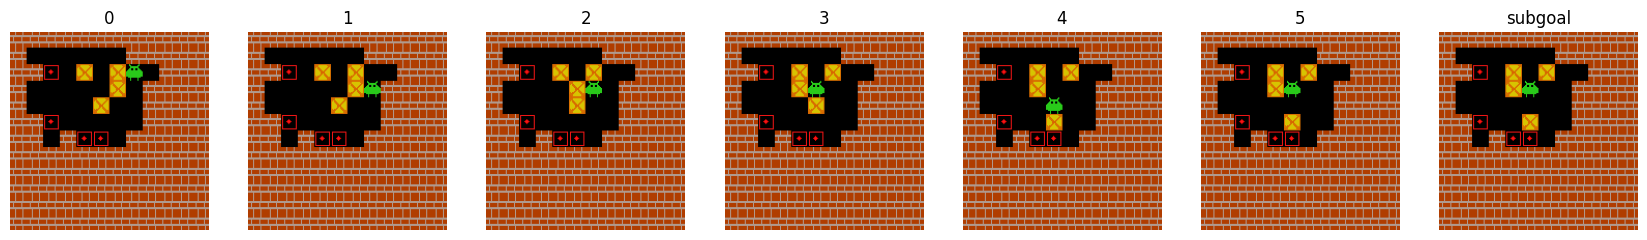

In [94]:
current_state: np.ndarray = dataset[keys[1]][1]
state_after_k: np.ndarray = dataset[keys[1]][6]

display(env.many_states_to_repr([current_state, state_after_k], ['current state', 'state after k=5']))

visited_states = []
env.core.restore_full_state_from_np_array_version(current_state)
for i in range(7):
    visited_states.append(current_state.copy())
    if np.array_equal(current_state, state_after_k):
        logger.success('Reached the goal state')
        break
    action = cllp.get_action(current_state, state_after_k)
    action = action.argmax()
    logger.info(f'Action: {action}')
    env.set_state(current_state)
    state, _, done, _ = env.step(action)

    current_state = state


env.many_states_to_repr(
    [*visited_states, state_after_k], [*list(range(len(visited_states))), 'subgoal']
)

# Value function

2025-12-28 19:07:27.822 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/value/checkpoint-1343100
2025-12-28 19:07:27.825 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:07:27.859 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/value/checkpoint-1343100


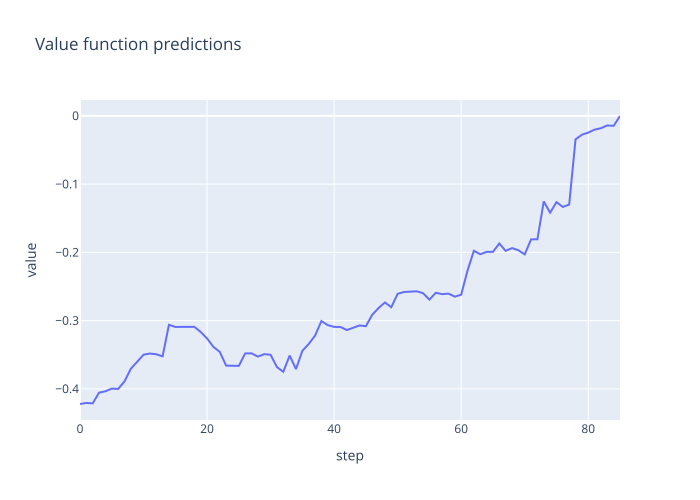

In [95]:
import plotly.graph_objects as go

value_function: Value = TransformerValue(
    value_network_class=BertForSequenceClassification.from_pretrained,
    path_to_value_network_weights=path_to_value_function_weights,
    env=env,
    type_of_evaluation='regression',
)

value_function.construct_network()
# value_function_prediction: float = value_function.get_value(current_state)
# solved_state = dataset[keys[1]][-1]
# logger.info(f'value function prediction of unsolved state: {value_function_prediction}')
# logger.info(f'value function prediction of solved state: {value_function.get_value(solved_state)}')
states = [state for state in dataset[keys[11]]]
values = [value_function.get_value(state) for state in states] # can be batched too


fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(values))), y=values))
fig.update_layout(title='Value function predictions', xaxis_title='step', yaxis_title='value')
fig.show()

# Goal Generator

2025-12-28 19:07:29.239 | INFO     | __main__:<module>:3 - setting up the subgoal generator
2025-12-28 19:07:29.241 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856
2025-12-28 19:07:29.245 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:07:29.502 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from /home/mtyrolski/dev/carl/CaRL/rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856


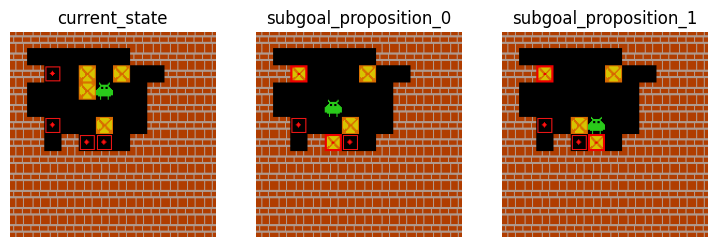

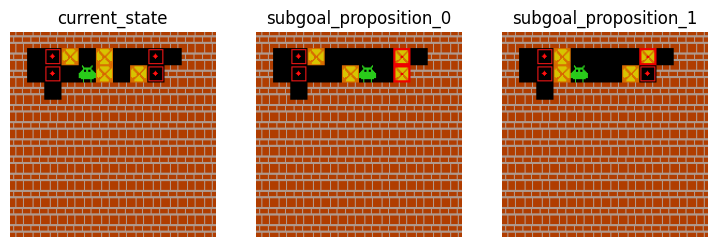

In [96]:
from carl.solver.nodes import SearchTreeNode

logger.info('setting up the subgoal generator')
subgoal_generation_kwargs: dict[str, int] = {
    'num_beams': 8,
    'num_return_sequences': 2,
    'max_new_tokens': 145,
}
generator: SubgoalGenerator = TransformerSubgoalGenerator(
    BartForConditionalGeneration.from_pretrained,
    path_to_generator_weights,
    env,
    subgoal_generation_kwargs,
)
generator.construct_network()

current_state2 = next(dataloader).cpu().numpy()[0]

nodes = [
    SearchTreeNode(
        state=current_state,
        value=0.0,
        low_level_path=[],
        parent_node=None,
        next_expand_with_k_generator=8,
    ),
    SearchTreeNode(
        state=current_state2,
        value=0.0,
        low_level_path=[],
        parent_node=None,
        next_expand_with_k_generator=8,
    ),
]

subgoals_0 = generator.get_subgoals(nodes[0])
subgoals_1 = generator.get_subgoals(nodes[1])

for input_node, subgoals in zip(nodes, [subgoals_0, subgoals_1]):
    fig = env.many_states_to_repr(
        [input_node.state, *[subgoal.state for subgoal in subgoals]],
        ['current_state', *[f'subgoal_proposition_{i}' for i in range(len(subgoals))]],
    )

    display(fig)



In [97]:
generator.get_network()

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(22, 512, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(22, 512, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(514, 512)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm

# CLLP with Goal Generator - evaluation

In [98]:
from importlib import reload
import carl.inference_components.cllp_utils as cllp_utils

reload(cllp_utils)

<module 'carl.inference_components.cllp_utils' from '/home/mtyrolski/dev/carl/CaRL/carl/inference_components/cllp_utils.py'>

## With generator-generated goals

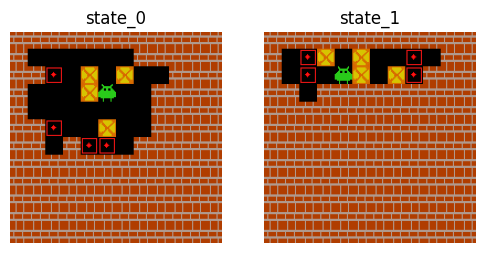

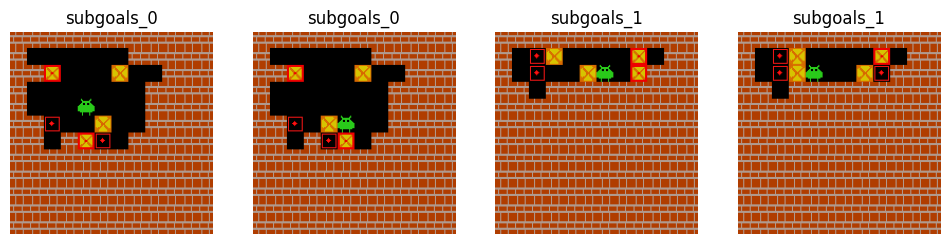

In [99]:
display(env.many_states_to_repr([node.state for node in nodes], ['state_0', 'state_1']))
subgoals_first = [subgoal.state for subgoal in subgoals_0]
subgoals_second = [subgoal.state for subgoal in subgoals_1]
env.many_states_to_repr([*subgoals_first, *subgoals_second], ['subgoals_0' for _ in range(len(subgoals_first))] + ['subgoals_1' for _ in range(len(subgoals_second))])

In [100]:
results = []
for input_node, subgoal_predictions in zip(nodes, [subgoals_0, subgoals_1]):
    cllp_ver_result = cllp_utils.verify_cllp_reaches_subgoals_from_initial_state(
        cllp=cllp,
        goals=[subgoal.state for subgoal in subgoal_predictions],
        initial_state=input_node.state,
        env_creation_fn=lambda: env,
        max_radius=10,
        add_first_batch_to_node_computations=True,
    )
    results.append(cllp_ver_result)
results

[CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 2, 2, 3, 1, 1, 1, 0], [0, 2, 2, 3, 1, 1, 3, 1]]),
 CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 3, 3, 3, 2, 1, 3, 2], [0, 3, 3, 3, 2, 1, 2, 2]])]

2025-12-28 19:07:41.903 | INFO     | __main__:<module>:7 - Verification result for node: CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 2, 2, 3, 1, 1, 1, 0], [0, 2, 2, 3, 1, 1, 3, 1]])


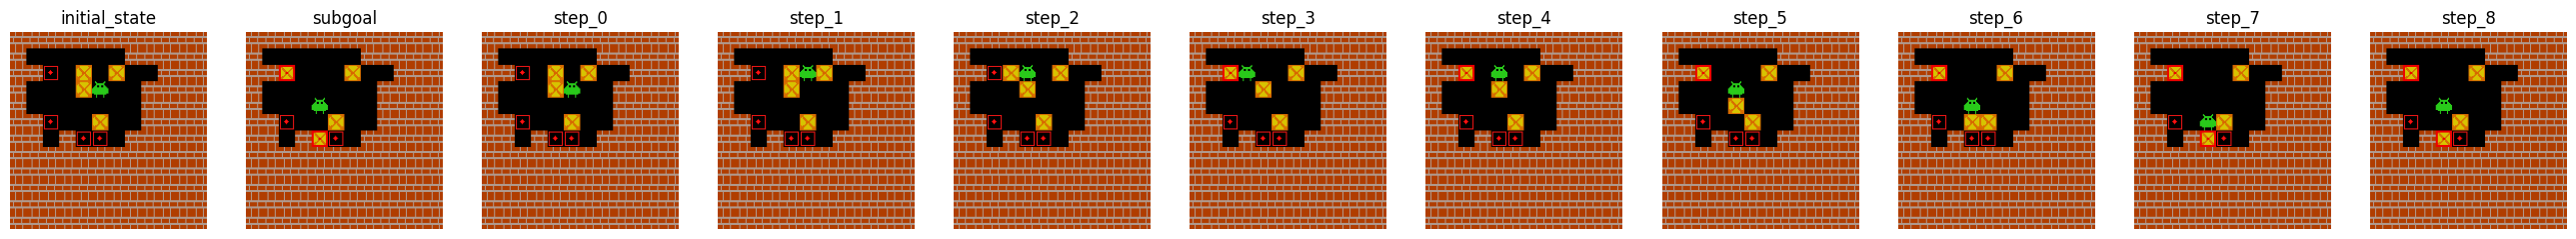

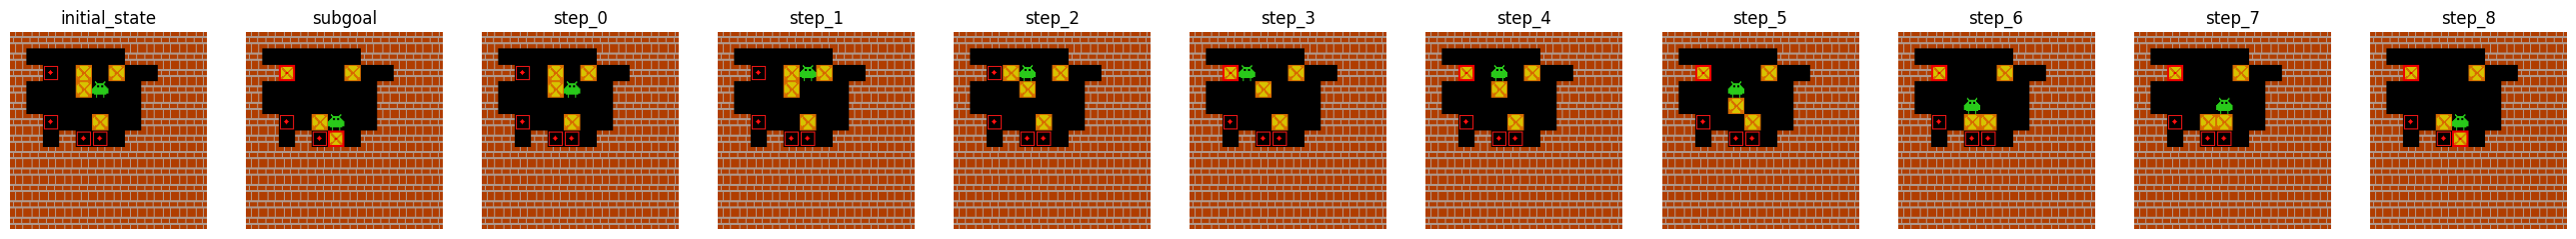

2025-12-28 19:07:44.528 | INFO     | __main__:<module>:7 - Verification result for node: CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 3, 3, 3, 2, 1, 3, 2], [0, 3, 3, 3, 2, 1, 2, 2]])


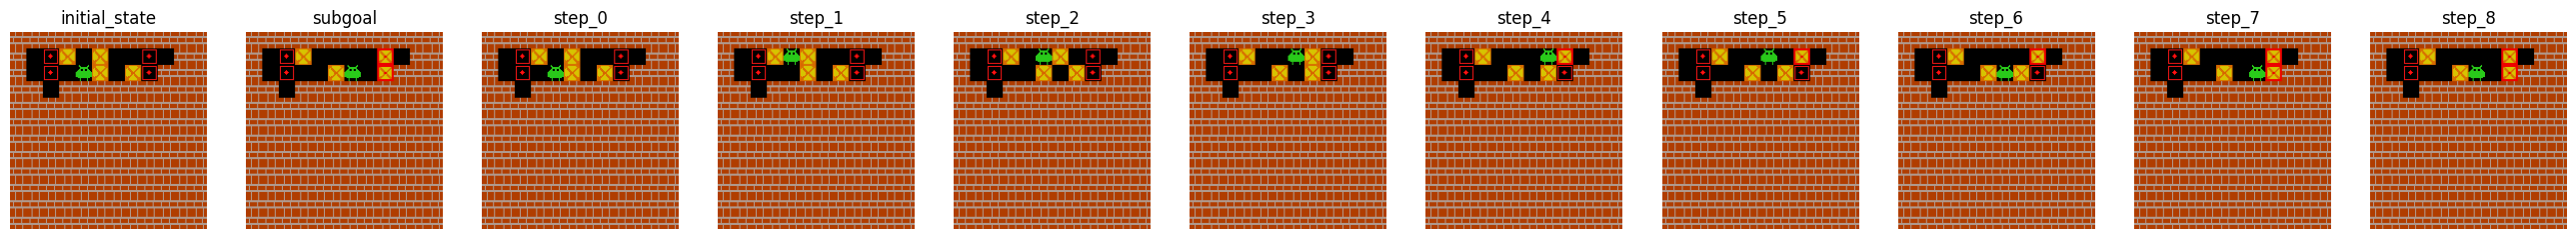

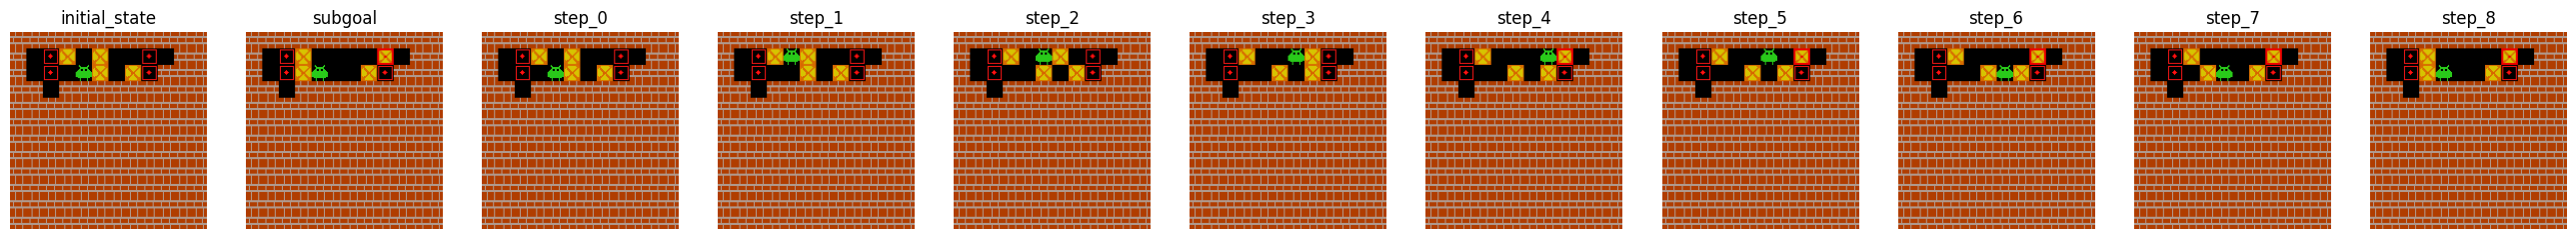

In [101]:
from carl.inference_components.validator import BasicValidator


validator = BasicValidator(env, cllp, 10)

for input_node, result, subgoals in zip(nodes, results, [subgoals_0, subgoals_1]):
    logger.info(f'Verification result for node: {result}')
    for i in range(len(result.paths)):
        trajectory = cllp_utils.trajectory_from_actions(env, input_node.state, result.paths[i])
        subgoal_state = subgoals[i].state
        display(env.many_states_to_repr([input_node.state, subgoal_state, *trajectory],
                                        ['initial_state', 'subgoal', *[f'step_{i}' for i in range(len(trajectory))]]))    

## With small, randomly generated goals

In [102]:
initial_state = next(dataloader).cpu().numpy()[0]

In [103]:
def get_goals(
    gen_env: SokobanEnv, gen_initial_state: np.ndarray, num_goals: int = 5, steps_to_goal: int = 7
) -> list[np.ndarray]:
    out_goals = []
    for _ in range(num_goals):
        gen_state = gen_initial_state.copy()
        for _ in range(steps_to_goal):
            action = np.random.randint(0, 4)
            gen_env.set_state(gen_state)
            gen_state, _, done, _ = gen_env.step(action)
            if done:
                break
        out_goals.append(gen_state.copy())
    return out_goals


random_small_goals = get_goals(
    gen_env=env, gen_initial_state=initial_state, num_goals=10, steps_to_goal=3
)

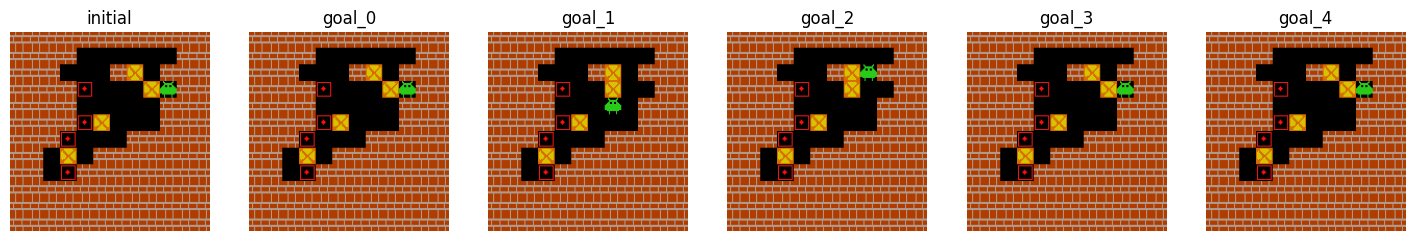

In [104]:
env.many_states_to_repr(
    [initial_state] + random_small_goals[:5],
    titles=['initial'] + [f'goal_{i}' for i in range(len(random_small_goals[:5]))],
)

In [105]:
cllp_utils.verify_cllp_reaches_subgoals_from_initial_state(
    cllp=cllp,
    goals=random_small_goals,
    initial_state=initial_state,
    env_creation_fn=lambda: env,
    max_radius=7,
    add_first_batch_to_node_computations=True,
)

CLLPVerificationResult(success_rate=1.0, total_goals=10, reached=array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True]), calls=10, cllp_samples_in_calls=14, node_computations=14, paths=[[3], [2, 1, 2], [2, 0], [3], [3], [3], [2, 0], [3], [3], [3]])

----

# NPuzzle Quick Demo

In [106]:
# NPuzzle components

from carl.environment.n_puzzle.env import NPuzzleEnv
from carl.environment.n_puzzle.tokenizer import NPuzzleTokenizer

npuzzle_env = NPuzzleEnv(
    tokenizer=NPuzzleTokenizer(size_of_board=(5, 5))
)
npuzzle_env

In [107]:
npuzzle_env

In [108]:
import joblib as jl
datapath = str(REPO_ROOT / "rl-data/validation/npuzzle/progress/fin/fin_puzzles_1000.pkl")
data = jl.load(datapath)

npuzzle_env.state_to_repr(data[0])

2025-12-28 19:07:47.792 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:384 - Representation type: RepresentationType.STR with value 3
2025-12-28 19:07:47.794 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:385 - Supported representation types: [<RepresentationType.STR: 3>, <RepresentationType.GO_FIGURE: 2>] with values [3, 2]


'[20 23  0  3  1  2 13 19  5 15 21  9 11  4 16  7 18 14 12  8 10 22 24  6\n 17]'

2025-12-28 19:07:47.818 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:384 - Representation type: RepresentationType.GO_FIGURE with value 2
2025-12-28 19:07:47.821 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:385 - Supported representation types: [<RepresentationType.STR: 3>, <RepresentationType.GO_FIGURE: 2>] with values [3, 2]


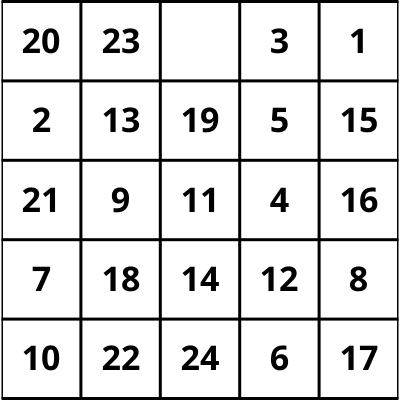

In [109]:
from carl.environment.env import RepresentationType


npuzzle_env.restore_full_state_from_np_array_version(data[0])
npuzzle_env.state_to_repr(npuzzle_env.get_state(), repr_type=RepresentationType.GO_FIGURE)

In [111]:
from carl.utils.notebook import instantiate_algorithm_from_grid

algo = instantiate_algorithm_from_grid('npuzzle_ada_solve', config_path='../../configs/solve/npuzzle', grid_entry_idx=0)

2025-12-28 19:15:54.311 | INFO     | carl.slurm.grid_search:validate_config:57 - Validating carl_grid syntax.
2025-12-28 19:15:54.342 | INFO     | carl.slurm.grid_search:validate_config:62 - Validating cartesian entry: {'subgoal_generator.generator_k_list': [[8, 4]], 'subgoal_generator.paths_to_generator_weights': [['./rl-data/validation/npuzzle/components/moe/generator/8/checkpoint-64090', './rl-data/validation/npuzzle/components/moe/generator/4/checkpoint-48314']], 'algorithm.result_logger.custom_logger.tags': [['inner_eval', 'npuzzle', 'AdaSubS', 'solve', 'k_84', '5x5']], 'subgoal_generator.subgoal_generation_kwargs.num_return_sequences': [1], 'validator.budget_for_achieving_subgoal': [10]}
2025-12-28 19:15:54.344 | INFO     | carl.slurm.grid_search:validate_config:78 - Validating key subgoal_generator.generator_k_list in config ['components_prefix', 'params', 'subgoal_generator', 'value_function', 'validator', 'algorithm', 'carl_workers']
2025-12-28 19:15:54.348 | INFO     | carl.s

Using Neptune API token: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJmYmIyNDk2Yi1kMmRiLTRhYmItYTRlMy00NjIyNzViN2Y3ZDAifQ==
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/mtyrol/drop/e/DROP-757


2025-12-28 19:15:55.671 | INFO     | carl.algorithms.solve_instances:__init__:57 - Using 4 parallel worker(s)


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] All 0 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/mtyrol/drop/e/DROP-755/metadata


In [112]:
from carl.solver.nodes import SearchTreeNode
planner = algo.solver.planner_class(data[0])
planner

In [113]:
node_k8 = planner.get()
node_k4 = planner.get()
node_others = planner.get()
assert node_k8 is not None
assert node_others is None

In [114]:
[node.next_expand_with_k_generator for node in (node_k8, node_k4) if node is not None]

[8]

In [115]:
algo.solver.construct_networks()

2025-12-28 19:15:55.900 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from ./rl-data/validation/npuzzle/components/moe/generator/8/checkpoint-64090
2025-12-28 19:15:55.908 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:15:56.247 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from ./rl-data/validation/npuzzle/components/moe/generator/8/checkpoint-64090
2025-12-28 19:15:56.258 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from ./rl-data/validation/npuzzle/components/moe/cllp/8/checkpoint-225736
2025-12-28 19:15:56.261 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:15:56.336 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from ./rl-data/validation/npuzzle/components/moe/cllp/

In [116]:
algo.solver.subgoal_generator.generator_k_list

[8]

In [117]:
print(algo.solver.subgoal_generator.subgoal_generators[8].sub_generator)

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(40, 256, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(40, 256, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(258, 256)
      (layers): ModuleList(
        (0-2): 3 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=256, out_features=256, bias=True)
          (fc2): Linear(in_features=256, out_features=256, bias=True)
          (final_layer_norm):

2025-12-28 19:15:58.901 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:384 - Representation type: RepresentationType.GO_FIGURE with value 2
2025-12-28 19:15:58.902 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:385 - Supported representation types: [<RepresentationType.STR: 3>, <RepresentationType.GO_FIGURE: 2>] with values [3, 2]


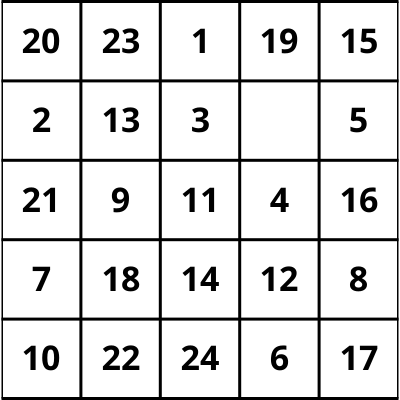

In [118]:
npuzzle_env.state_to_repr(algo.solver.subgoal_generator.get_subgoals(node_k8)[0].state, repr_type=RepresentationType.GO_FIGURE)

In [135]:
if node_k4 is not None:
    display(npuzzle_env.state_to_repr(
        algo.solver.subgoal_generator.get_subgoals(node_k4)[0].state,
        repr_type=RepresentationType.GO_FIGURE,
    ))

2025-12-28 19:16:00.611 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:384 - Representation type: RepresentationType.GO_FIGURE with value 2
2025-12-28 19:16:00.615 | WARNING  | carl.environment.n_puzzle.env:state_to_repr:385 - Supported representation types: [<RepresentationType.STR: 3>, <RepresentationType.GO_FIGURE: 2>] with values [3, 2]


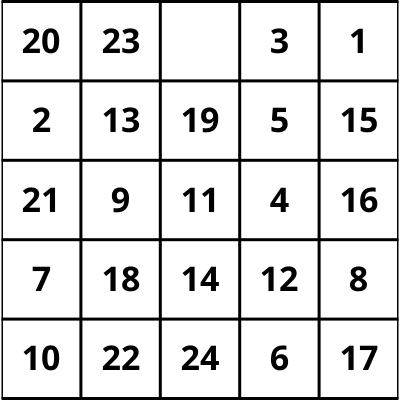

In [120]:
npuzzle_env.restore_full_state_from_np_array_version(data[0])
npuzzle_env.state_to_repr(npuzzle_env.get_state(), repr_type=RepresentationType.GO_FIGURE)

------

# Rubik

In [121]:
# Rubik'

from carl.utils.notebook import instantiate_algorithm_from_grid

algo = instantiate_algorithm_from_grid('rubik_ada_solve', config_path='../../configs/solve/rubik', grid_entry_idx=0)


2025-12-28 19:16:01.166 | INFO     | carl.slurm.grid_search:validate_config:57 - Validating carl_grid syntax.
2025-12-28 19:16:01.193 | INFO     | carl.slurm.grid_search:validate_config:62 - Validating cartesian entry: {'subgoal_generator.generator_k_list': [[4, 2]], 'subgoal_generator.paths_to_generator_weights': [['./rl-data/validation/rubik/components/shuffle_70/generator/4/checkpoint-270710', './rl-data/validation/rubik/components/shuffle_70/generator/2/checkpoint-270710']], 'validator.cllp.path_to_conditional_low_level_policy_weights': ['./rl-data/validation/rubik/components/shuffle_70/cllp/4/checkpoint-141063'], 'algorithm.result_logger.custom_logger.tags': [['inner_eval', 'rubik', 'AdaSubS', 'solve', 'k_42', 'shuffle_general']], 'subgoal_generator.subgoal_generation_kwargs.num_return_sequences': [1], 'validator.budget_for_achieving_subgoal': [6]}
2025-12-28 19:16:01.194 | INFO     | carl.slurm.grid_search:validate_config:78 - Validating key subgoal_generator.generator_k_list in 

Using Neptune API token: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJmYmIyNDk2Yi1kMmRiLTRhYmItYTRlMy00NjIyNzViN2Y3ZDAifQ==
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/mtyrol/drop/e/DROP-758


2025-12-28 19:16:02.541 | INFO     | carl.algorithms.solve_instances:__init__:57 - Using 4 parallel worker(s)


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] All 0 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/mtyrol/drop/e/DROP-757/metadata


In [122]:
import joblib

ds = joblib.load(str(REPO_ROOT / "rl-data/validation/rubik/progress/shuffle_general/rubik_eval_data_part_shuffle_1000_0.pkl"))
ds[:3]

['gbbgywbwoyorybgrogyowrrbrrobryoggwgworoyobrbbyygywwwwg',
 'orwwyrryowogwbbrrgybborbygbyybwgyrwrobgoogbgwoywgwrgoy',
 'ogbryrwyrwbgbbgbwwroywrwbrgbgorgyybywoggoygoyryoowwobr']

In [123]:
algo.solver.construct_networks()

2025-12-28 19:16:02.671 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from ./rl-data/validation/rubik/components/moe_uniform/generator/8/checkpoint-279639
2025-12-28 19:16:02.683 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:16:02.971 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from ./rl-data/validation/rubik/components/moe_uniform/generator/8/checkpoint-279639
2025-12-28 19:16:02.984 | DEBUG    | carl.inference_components.component:instantiate_network:61 - Loading weights from ./rl-data/validation/rubik/components/moe_uniform/cllp/8/checkpoint-1904720
2025-12-28 19:16:02.985 | INFO     | carl.inference_components.component:instantiate_network:83 - Provided direct path to the ckpt
2025-12-28 19:16:03.042 | SUCCESS  | carl.inference_components.component:instantiate_network:95 - Loaded weights from ./rl-data/validation/rubik/c

In [124]:
root_state = 'gbbgywbwoyorybgrogyowrrbrrobryoggwgworoyobrbbyygywwwwg'

In [125]:
algo.solver.planner_class

functools.partial(<class 'carl.planners.adasubs.AdasubsPlanner'>, generators_k_list=[8])

In [126]:

from carl.planners.adasubs import AdasubsPlanner


planner: AdasubsPlanner = algo.solver.planner_class(root_state)
len(planner.nodes_queue)

1

In [127]:
retrieved_nodes = []
for _ in range(3):
    node = planner.get()
    if node is None:
        break
    retrieved_nodes.append(node)

retrieved_nodes

[SearchTreeNode(state.shape=(54,), value=0, next_expand_k=8)]

In [128]:
subgoals_k8 = []
subgoals_k4 = []
if retrieved_nodes:
    subgoals_k8 = algo.solver.subgoal_generator.get_subgoals(retrieved_nodes[0])
if len(retrieved_nodes) > 1:
    subgoals_k4 = algo.solver.subgoal_generator.get_subgoals(retrieved_nodes[1])

In [129]:
from carl.inference_components.cllp_utils import verify_cllp_reaches_subgoals_from_initial_state
if len(retrieved_nodes) > 1 and subgoals_k4:
    verify_cllp_reaches_subgoals_from_initial_state(
        cllp=algo.solver.validator.cllp,
        goals=[subgoal.state for subgoal in subgoals_k4],
        initial_state=retrieved_nodes[1].state,
        env_creation_fn=lambda: algo.solver.subgoal_generator.env,
        max_radius=10,
    )
else:
    print('No k=4 node available for CLLP verification.')

No k=4 node available for CLLP verification.


---- 

In [130]:
from carl.environment.gym_rubik.rubik_env import RubikEnv
from carl.environment.gym_rubik.tokenizer import RubikCubeTokenizer
rubik_env = RubikEnv(RubikCubeTokenizer())

state_before_set = rubik_env.get_state()
state_before_set

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       [[3, 3, 3],
        [3, 3, 3],
        [3, 3, 3]],

       [[4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]],

       [[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]]])

In [131]:
rubik_env.restore_full_state_from_np_array_version(root_state)
state_after_set = rubik_env.get_state()
state_after_set

array([[[5, 4, 4],
        [1, 0, 5],
        [3, 1, 5]],

       [[1, 0, 0],
        [1, 1, 0],
        [4, 1, 4]],

       [[2, 2, 0],
        [2, 2, 3],
        [3, 5, 1]],

       [[2, 0, 3],
        [5, 3, 2],
        [5, 5, 3]],

       [[1, 3, 5],
        [4, 4, 2],
        [1, 4, 0]],

       [[2, 0, 0],
        [3, 5, 3],
        [4, 4, 2]]])

In [132]:
# Debug: Compare current state and subgoal state strings for Rubik's Cube

# Example: Use the first subgoal from subgoals_k8 (adjust as needed for your setup)
if len(subgoals_k8) > 0:
    subgoal_state = subgoals_k8[0].state
    current_state = retrieved_nodes[0].state
    print('Current state:', current_state)
    print('Subgoal state:', subgoal_state)
    print('Are they string-equal?', current_state == subgoal_state)
    # Optionally, visualize both states if you have a visualization function
    # print(rubik_env.state_to_repr(current_state, title='Current'))
    # print(rubik_env.state_to_repr(subgoal_state, title='Subgoal'))
else:
    print('No subgoals found to compare.')


Current state: gbbgywbwoyorybgrogyowrrbrrobryoggwgworoyobrbbyygywwwwg
Subgoal state: gwbyygybgorryboroogrobrryrbyorgggwgwyowyobrbbbwoywwwwg
Are they string-equal? False


In [133]:
# Try all possible actions from the current state and print resulting states
from carl.environment.gym_rubik.rubik_env import ACTION_LOOKUP
import numpy as np
if len(subgoals_k8) > 0:
    subgoal_state = subgoals_k8[0].state
    current_state = retrieved_nodes[0].state
    print('Current state:', current_state)
    print('Subgoal state:', subgoal_state)
    print('Trying all actions from current state:')
    for action_idx in range(len(ACTION_LOOKUP)):
        # Reset environment to current state
        rubik_env.restore_full_state_from_np_array_version(current_state)
        # Take action
        next_state, _, _, _ = rubik_env.step(action_idx)
        print(f'Action {action_idx} ({rubik_env.action_name(action_idx)}): {next_state}')
        if np.array_equal(next_state, subgoal_state):
            print(f'--> Subgoal reached with action {action_idx}!')
else:
    print('No subgoals found to test actions.')


Current state: gbbgywbwoyorybgrogyowrrbrrobryoggwgworoyobrbbyygywwwwg
Subgoal state: gwbyygybgorryboroogrobrryrbyorgggwgwyowyobrbbbwoywwwwg
Trying all actions from current state:
Action 0 (U): [[[3 1 5]
  [1 0 4]
  [5 5 4]]

 [[1 0 0]
  [1 1 0]
  [4 1 4]]

 [[2 2 5]
  [2 2 2]
  [3 5 0]]

 [[2 0 0]
  [5 3 3]
  [5 5 2]]

 [[1 3 3]
  [4 4 2]
  [1 4 3]]

 [[2 0 0]
  [3 5 3]
  [4 4 1]]]
Action 1 (U_1): [[[4 5 5]
  [4 0 1]
  [5 1 3]]

 [[1 0 0]
  [1 1 0]
  [4 1 4]]

 [[2 2 0]
  [2 2 3]
  [3 5 2]]

 [[2 0 5]
  [5 3 2]
  [5 5 0]]

 [[1 3 0]
  [4 4 3]
  [1 4 1]]

 [[2 0 3]
  [3 5 2]
  [4 4 3]]]
Action 2 (D): [[[5 4 4]
  [1 0 5]
  [3 1 5]]

 [[4 1 1]
  [1 1 0]
  [4 0 0]]

 [[2 2 0]
  [3 2 3]
  [4 5 1]]

 [[1 0 3]
  [4 3 2]
  [1 5 3]]

 [[2 3 5]
  [2 4 2]
  [3 4 0]]

 [[2 0 0]
  [5 5 3]
  [5 4 2]]]
Action 3 (D_1): [[[5 4 4]
  [1 0 5]
  [3 1 5]]

 [[0 0 4]
  [0 1 1]
  [1 1 4]]

 [[1 2 0]
  [4 2 3]
  [1 5 1]]

 [[2 0 3]
  [3 3 2]
  [4 5 3]]

 [[2 3 5]
  [5 4 2]
  [5 4 0]]

 [[2 0 0]
  [2 5 3]
  [3 

### Verification that the CLLP work without generator - so by artificially extracted goals from trajectories

In [134]:
from carl.inference_components.cllp_utils import CLLPVerificationResult

import numpy as np
trajectories = joblib.load(str(REPO_ROOT / "rl-data/validation/rubik/offiline/shuffle_100/rubik_offline_data_part_1.pkl"))
first_key = next(iter(trajectories.keys()))
selected_trajectory = trajectories[first_key]
L = len(selected_trajectory)
N = 100


random_ids_begins = np.random.randint(0, L - N, size=N)
random_shifts = np.random.randint(1, 5, size=N)

hit_rates: list[CLLPVerificationResult] = []
for j in range(N):
    begin = random_ids_begins[j]
    shift = random_shifts[j]
    is_reachable = verify_cllp_reaches_subgoals_from_initial_state(
        cllp=algo.solver.validator.cllp,
        goals=[selected_trajectory[begin + shift]],
        initial_state=selected_trajectory[begin],
        env_creation_fn=lambda: algo.solver.subgoal_generator.env,
        max_radius=5,
    )
    hit_rates.append(is_reachable)
    
hit_rate = sum([hr.success_rate for hr in hit_rates]) / len(hit_rates)
hit_rate

1.0